(mmm_control_dimensionality)=
# When More Controls Affect ROAS Estimation: An R2D2 Case Study

Stakeholders often ask an MMM to include every plausible control. That can be sensible, but it has a prior consequence: with fixed independent priors, every added control or routine Fourier term expands the nuisance block's prior explanatory capacity. The data must then overcome a more permissive nuisance prior before variation is attributed to media. A split R2D2 prior offers a dimension-aware alternative: it divides one shared control-and-seasonality budget across however many nuisance coefficients are present.

This notebook separates three levels of evidence:

1. **Prior mechanism:** how does the nuisance block's prior capacity change as its dimension grows?
2. **One realization:** how can that mechanism appear in a fitted MMM?
3. **Repeated performance:** across independently generated MMM datasets, how do bias, sampling variation, posterior uncertainty, and coverage of total media ROAS change?

The repeated study is the inferential comparison. The single fitted dataset is deliberately retained as an illustration only: a split R2D2 prior is not guaranteed to be closer to truth in every realization.

Controls and media are independent in this data-generating process, making the controls neutral rather than confounders. Finite samples can still have incidental correlations and therefore move attribution in one fit; repetition averages that random overlap. This is not evidence about the case where spend follows controls or seasonality.


## Experimental design

Every model contains order-2 yearly seasonality: `sin_1`, `sin_2`, `cos_1`, and `cos_2`. The data-generating process contains only `sin_1`; the other three Fourier coefficients are exactly zero. They are realistic nuisance parameters introduced by a routine MMM seasonality choice, and they share the R2D2 budget with controls.

There are 25 exported controls. The first 10 have meaningful, decreasing effects. Controls 11–25 have tiny but nonzero decreasing effects: each is below an approximate likelihood-only uncertainty scale, and together they add little true signal but substantial nuisance dimensionality.

The design deliberately separates two expansions:

- **$5\rightarrow10$:** add useful neutral prognostic controls;
- **$10\rightarrow25$:** add mostly nuisance control dimensions;
- **$5\rightarrow25$:** compare a parsimonious MMM with the broad control list a stakeholder may request.

The prior and one-dataset illustration use $K\in\{0,5,10,25\}$; the repeated study uses $K\in\{5,10,25\}$. $K=0$ is useful for exposing the prior mechanism, but it omits genuine prognostic controls and is conditionally misspecified. Neutrality protects the media estimand from systematic omitted-variable bias over repetitions; it does not make that conditional outcome model correct.


## Prepare notebook


In [1]:
import contextlib
import io
import warnings

import arviz as az
import matplotlib.pyplot as plt
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from pytensor.xtensor.type import as_xtensor

from pymc_marketing.constants import DAYS_IN_YEAR
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.fourier import YearlyFourier
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.scaling import DataDerivedScaling, Scaling
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
from pymc_marketing.r2d2 import R2D2

warnings.filterwarnings("ignore", category=FutureWarning)
az.style.use("arviz-darkgrid")
plt.rcParams.update({"figure.figsize": [10, 6], "figure.dpi": 100, "figure.facecolor": "white"})

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"


In [2]:
SEED = 42
N_DATES = 130  # two and a half years of weekly data
N_CHANNELS = 5
N_CONTROLS = 25
N_MEANINGFUL_CONTROLS = 10
L_MAX = 8
CONTROL_PHI = 0.85
CHOL_ETA = 10.0
FOURIER_ORDER = 2

K_GRID = [0, 5, 10, 25]
REPEATED_K_GRID = [5, 10, 25]
CHANNELS = [f"x{i + 1}" for i in range(N_CHANNELS)]
CONTROLS = [f"c{i + 1}" for i in range(N_CONTROLS)]
DATES = pd.date_range("2021-01-04", freq="W-MON", periods=N_DATES)
FOURIER_NODES = YearlyFourier(n_order=FOURIER_ORDER, prefix="fourier_mode").nodes
PHANTOM_NODES = [node for node in FOURIER_NODES if node != "sin_1"]


## Data-generating process

Spend is correlated across channels and changes smoothly over time. It is generated independently of both the controls and the calendar. The true media contribution uses the same normalized geometric adstock and logistic saturation transformations as the fitted MMM.

The target and the fitted model both use max scaling. Controls are standardized because `MMM` does not scale controls automatically and the R2D2 coefficient budget only has a common interpretation when predictors are on comparable scales.


In [3]:
def draw_spend(rng: np.random.Generator) -> np.ndarray:
    """Draw correlated, trending, non-negative channel spend."""
    coords = {"channel": CHANNELS, "date": np.arange(N_DATES)}
    t = np.arange(N_DATES) / N_DATES
    with pm.Model(coords=coords) as spend_model:
        t_data = pm.Data("t", t, dims="date")
        chol, _, _ = pm.LKJCholeskyCov(
            "chol",
            n=N_CHANNELS,
            eta=CHOL_ETA,
            sd_dist=pm.Gamma.dist(alpha=6, beta=2),
        )
        intercept = pm.Normal("spend_intercept", 0, 1, dims="channel")
        slope = pm.Normal("spend_slope", 0, 1, dims="channel")
        mu = intercept + slope * t_data[..., None]
        raw = pm.MvNormal("raw_spend", mu=mu, chol=chol, dims=("date", "channel"))
        spend = pm.Deterministic("spend", pt.softplus(raw), dims=("date", "channel"))
    return pm.draw(spend, draws=1, random_seed=rng)


def media_shape(spend_scaled: np.ndarray, alpha: np.ndarray, lam: np.ndarray) -> np.ndarray:
    """Adstock then saturate at unit beta, matching the MMM forward pass."""
    adstocked = geometric_adstock(
        as_xtensor(spend_scaled, dims=("date", "channel")),
        alpha=as_xtensor(alpha, dims=("channel",)),
        l_max=L_MAX,
        dim="date",
        normalize=True,
    )
    saturated = logistic_saturation(adstocked, lam=as_xtensor(lam, dims=("channel",)))
    return saturated.transpose("date", "channel").values.eval()


In [4]:
def simulate(
    seed: int,
    *,
    media_contribution_share: float = 0.15,
    true_r2: float = 0.75,
    delta_media: float = 0.20,
    baseline: float = 1.0,
    spend_to_revenue: float = 0.075,
) -> tuple[pd.DataFrame, dict]:
    """Generate one MMM dataset and its exact latent truth."""
    rng = np.random.default_rng(seed)
    spend_raw = draw_spend(rng)
    spend_scaled = spend_raw / spend_raw.max(axis=0)

    # Alpha and lambda are drawn from the same priors used in the fitted MMM.
    # Beta is calibrated, rather than drawn, to achieve the requested media share.
    alpha_true = rng.beta(1, 3, size=N_CHANNELS)
    lam_true = rng.gamma(shape=3, scale=1, size=N_CHANNELS)
    shape = media_shape(spend_scaled, alpha_true, lam_true)
    beta_relative = 1 / shape.mean(axis=0)
    unit_media = shape @ beta_relative
    media_mean = media_contribution_share * baseline / (1 - media_contribution_share)
    beta_true = beta_relative * media_mean / unit_media.mean()
    media = shape @ beta_true

    # Slot 0 is true sin_1 and is never exported as a control. The next 25
    # slots are independent persistent candidate controls.
    columns = np.empty((N_DATES, N_CONTROLS + 1))
    columns[:, 0] = np.sin(2 * np.pi * DATES.dayofyear.to_numpy() / DAYS_IN_YEAR)
    columns[0, 1:] = rng.normal(size=N_CONTROLS)
    innovations = rng.normal(
        scale=np.sqrt(1 - CONTROL_PHI**2), size=(N_DATES, N_CONTROLS)
    )
    for t in range(1, N_DATES):
        columns[t, 1:] = CONTROL_PHI * columns[t - 1, 1:] + innovations[t]

    seasonal_raw = columns[:, 0].copy()
    columns = (columns - columns.mean(axis=0)) / columns.std(axis=0)

    meaningful = np.exp(-0.10 * np.arange(N_MEANINGFUL_CONTROLS))
    nuisance = 0.05 * np.exp(
        -0.10 * np.arange(N_CONTROLS - N_MEANINGFUL_CONTROLS)
    )
    importance = np.concatenate([[1.0], meaningful, nuisance])

    var_media = media.var()
    block_budget = var_media * (1 - delta_media) / delta_media
    ladder_signal = columns @ importance
    gamma = importance * np.sqrt(block_budget / ladder_signal.var())

    seasonal_std = seasonal_raw.std()
    gamma_fourier = gamma[0] / seasonal_std
    intercept_offset = -gamma[0] * seasonal_raw.mean() / seasonal_std
    seasonal = gamma_fourier * seasonal_raw
    control = columns[:, 1:] @ gamma[1:]

    explained = media + seasonal + control
    sigma_true = np.sqrt(explained.var() * (1 - true_r2) / true_r2)
    noise = rng.normal(scale=sigma_true, size=N_DATES)
    y_raw = baseline + intercept_offset + explained + noise
    target_scale = y_raw.max()
    y = y_raw / target_scale

    spend_level = spend_to_revenue * y.sum() / spend_raw.sum()
    spend = spend_raw * spend_level

    gamma_fourier_vector = np.zeros(len(FOURIER_NODES))
    gamma_fourier_vector[FOURIER_NODES.index("sin_1")] = gamma_fourier / target_scale

    truth = {
        "intercept": (baseline + intercept_offset) / target_scale,
        "adstock_alpha": alpha_true,
        "saturation_lam": lam_true,
        "saturation_beta": beta_true / target_scale,
        "gamma_control": gamma[1:] / target_scale,
        "gamma_fourier": gamma_fourier_vector,
        "y_sigma": sigma_true / target_scale,
        "media_contribution": media / target_scale,
        "control_contribution": control / target_scale,
        "seasonal_contribution": seasonal / target_scale,
        "total_roas": (media / target_scale).sum() / spend.sum(),
        "target_scale": target_scale,
    }
    truth["r2"] = explained.var() / (explained.var() + sigma_true**2)

    frame = {"date": DATES}
    frame |= {name: spend[:, i] for i, name in enumerate(CHANNELS)}
    frame |= {name: columns[:, i + 1] for i, name in enumerate(CONTROLS)}
    frame["y"] = y
    return pd.DataFrame(frame), truth


In [5]:
data, truth = simulate(SEED)

n_eff = N_DATES * (1 - CONTROL_PHI) / (1 + CONTROL_PHI)
noise_identification_scale = truth["y_sigma"] / np.sqrt(n_eff)
tail = truth["gamma_control"][N_MEANINGFUL_CONTROLS:]
full_control = truth["control_contribution"]
tail_control = (
    data[CONTROLS[N_MEANINGFUL_CONTROLS:]].to_numpy() @ tail
)

assert np.all(np.abs(tail) < noise_identification_scale)
assert tail_control.var() / full_control.var() < 0.05

pd.Series(
    {
        "true total ROAS": truth["total_roas"],
        "true residual sigma": truth["y_sigma"],
        "approximate coefficient noise scale": noise_identification_scale,
        "largest tail coefficient": np.abs(tail).max(),
        "all tail coefficients below noise scale": bool(
            np.all(np.abs(tail) < noise_identification_scale)
        ),
        "tail variance / full control variance": tail_control.var() / full_control.var(),
        "true R-squared": truth["r2"],
    }
)


true total ROAS                            2.013322
true residual sigma                        0.059172
approximate coefficient noise scale        0.018226
largest tail coefficient                   0.002421
all tail coefficients below noise scale        True
tail variance / full control variance      0.009212
true R-squared                                 0.75
dtype: object

The checks above operationalize “mostly nuisance”: the last 15 effects are nonzero, but each is below an approximate likelihood-only coefficient uncertainty based on the effective sample size of an AR(1) series. Their realized aggregate variance is also reported rather than inferred from squared coefficients, because the persistent columns are correlated in a finite sample.


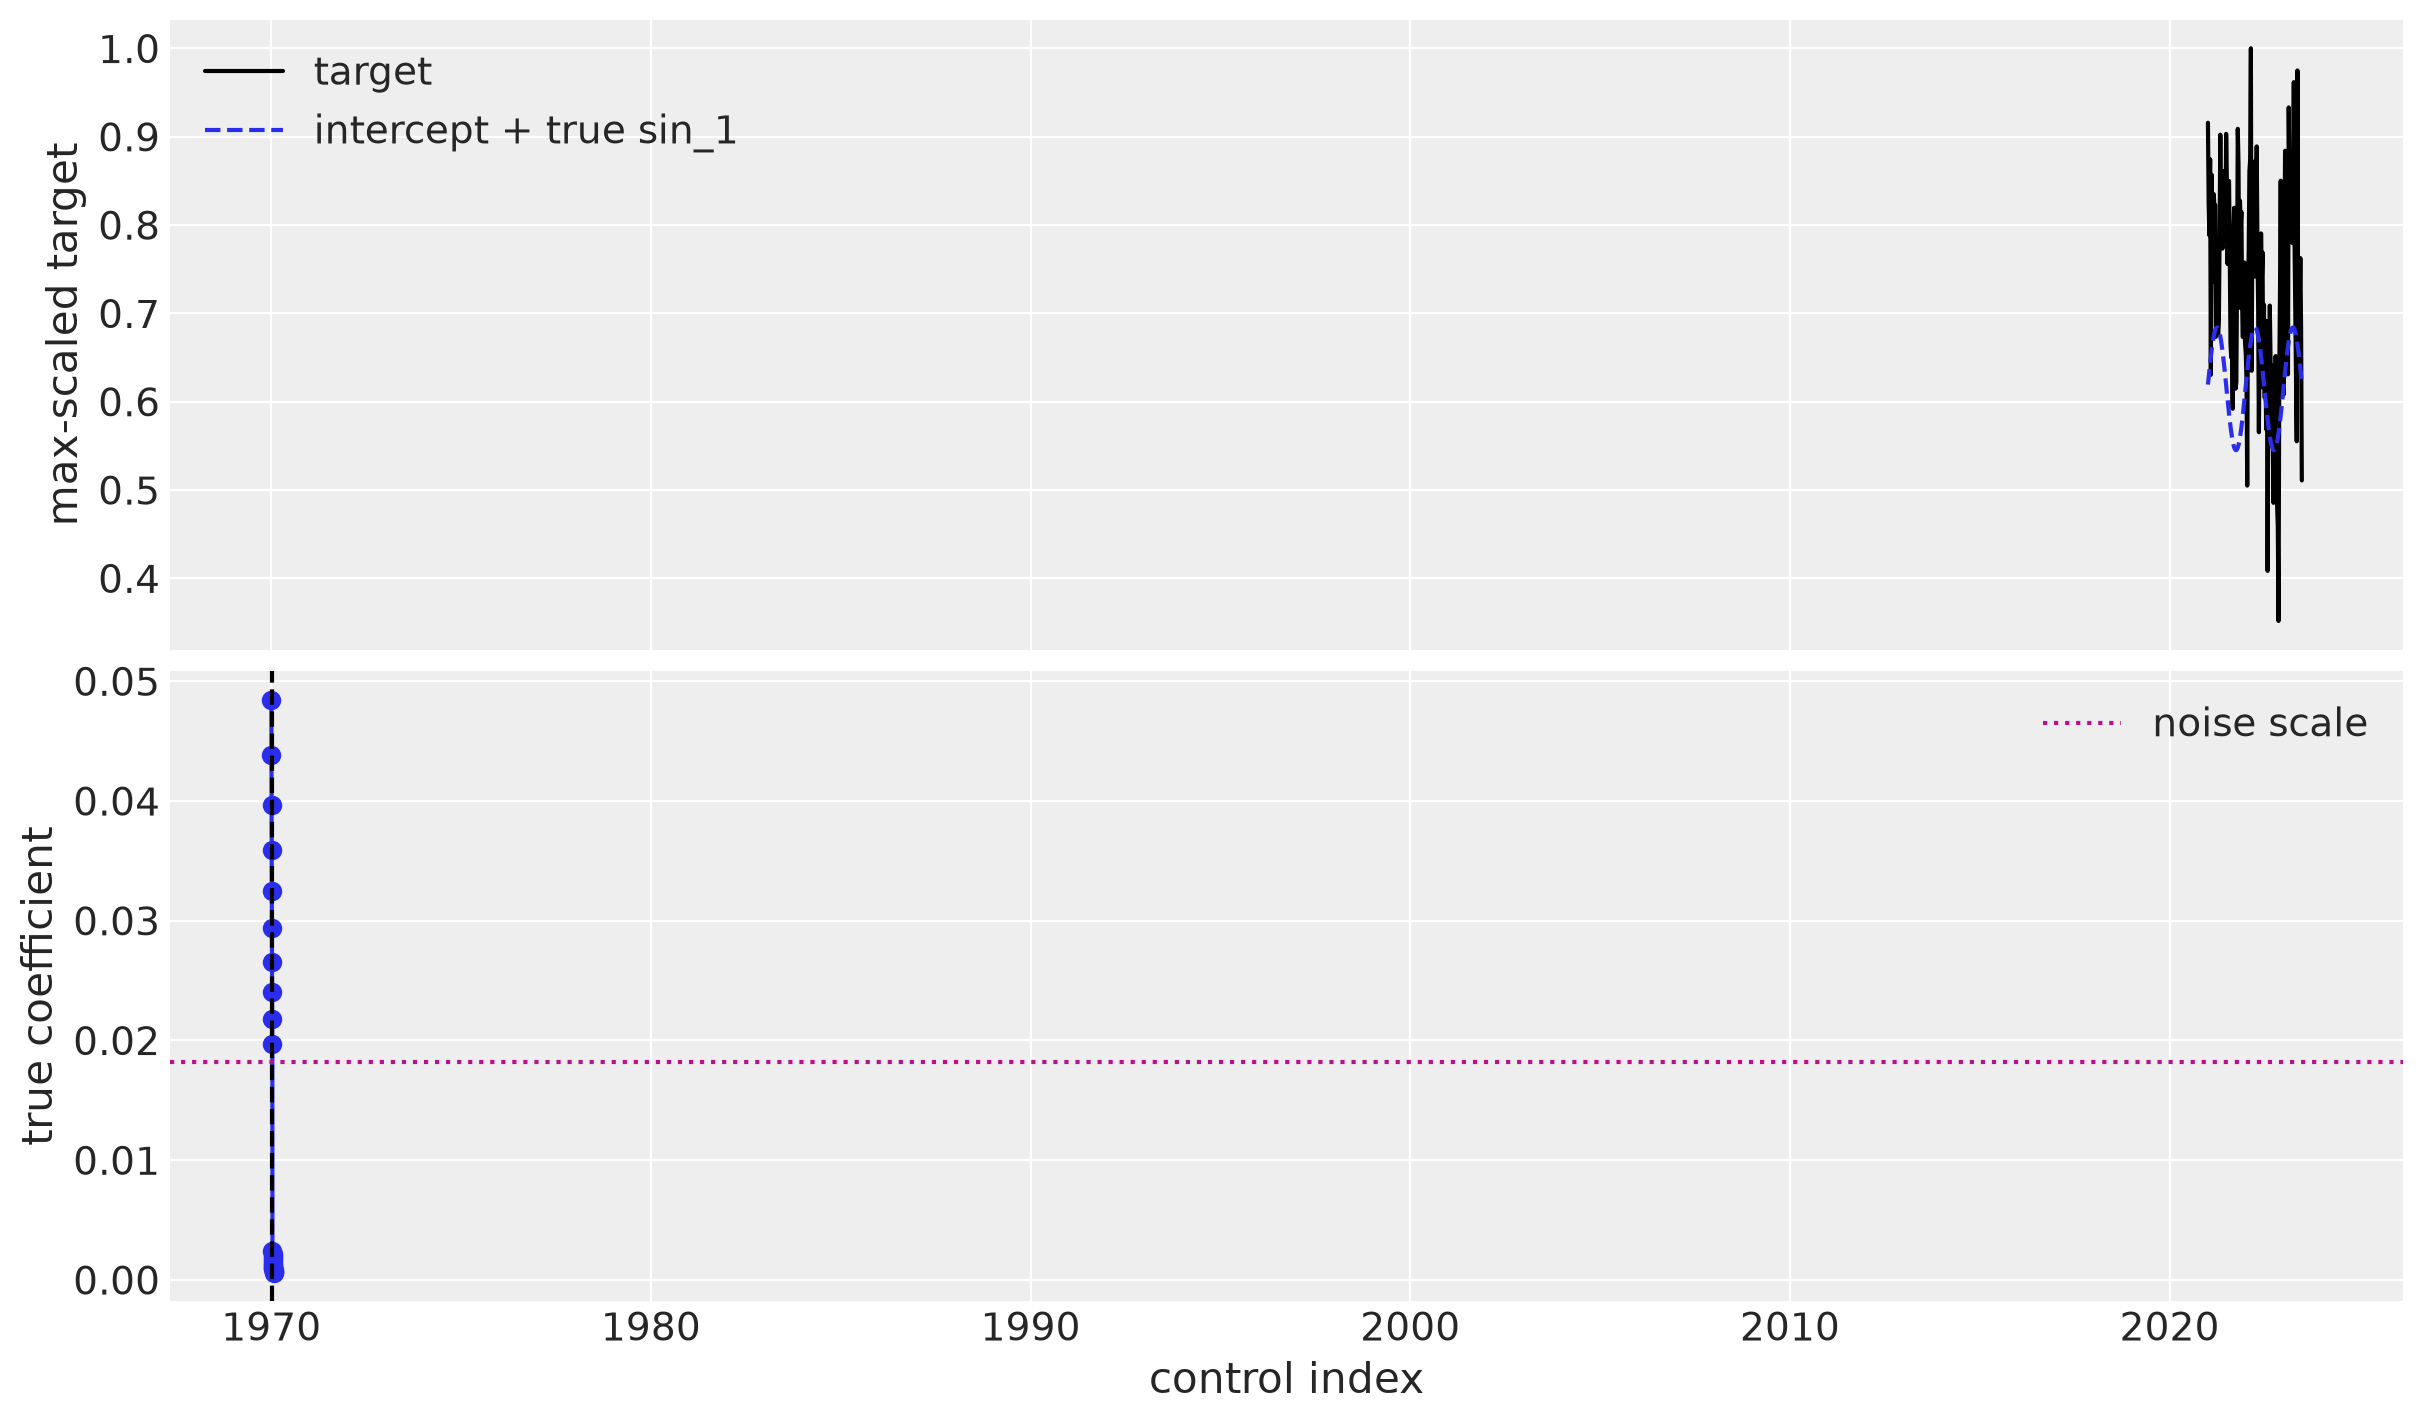

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, layout="constrained")
axes[0].plot(data["date"], data["y"], color="black", label="target")
axes[0].plot(
    data["date"],
    truth["intercept"] + truth["seasonal_contribution"],
    linestyle="--",
    label="intercept + true sin_1",
)
axes[0].legend()
axes[0].set(ylabel="max-scaled target")

axes[1].plot(range(1, N_CONTROLS + 1), truth["gamma_control"], marker="o")
axes[1].axvline(N_MEANINGFUL_CONTROLS + 0.5, color="black", linestyle="--")
axes[1].axhline(noise_identification_scale, color="C3", linestyle=":", label="noise scale")
axes[1].set(xlabel="control index", ylabel="true coefficient")
axes[1].legend()
plt.show()


## Prior systems

The comparison is between two complete prior systems:

- **Independent:** the library's fixed-scale independent priors for controls and Fourier terms, with an independent residual-scale prior.
- **Split R2D2:** one R2D2 decomposition shared by controls and Fourier terms, leaving media priors untouched. Native R2D2 also determines residual sigma, so this is not an isolated coefficient-prior substitution.

R2D2 provides a coefficient-scale budget whose expected variance interpretation relies on standardized predictors. It does **not** hard-fix the realized $\operatorname{Var}(X\gamma)$ for a correlated finite-sample design. We therefore inspect both its coefficient budget and the actual prior-predictive variance of the summed linear predictor. The fits use the non-centered R2D2 parameterization (`centered=False`) so coefficients are sampled through standard-normal offsets despite their stochastic local scales.

The R2D2 scale below is calibrated from the observed target variance. This is transparent empirical-Bayes/data-derived calibration, not pre-data prior elicitation. The dimensionless beliefs are that a useful MMM explains roughly 70% of target variance and media accounts for roughly 30% of the explained variance.

### Relationship to Riha et al. (2026)

This is an MMM translation of the prior-geometry question in [Riha et al. (2026)](https://arxiv.org/abs/2606.22850), *To select or not to select: predictively consistent priors instead of model selection*. Their central concern is whether prior-predictive implications remain sensible as a model expands. Here, the expansion is a control-and-seasonality nuisance block and the practical estimand is total media ROAS. The analogy is deliberately incomplete: the model is nonlinear, controls are persistent, media priors remain outside the R2D2 decomposition, and the outcome is not an out-of-sample predictive-utility comparison. Accordingly, this notebook demonstrates a dimension-aware variance-budget mechanism; it does not claim that the implemented prior formally satisfies the paper's definition of predictive consistency.


In [7]:
R2_TOTAL_BELIEF = 0.70
DELTA_MEDIA_BELIEF = 0.30
R2_PRECISION = 22.0
SIGMA_REF = 0.10


def make_r2d2(k: int, target_variance: float) -> R2D2:
    r2_mean = (
        R2_TOTAL_BELIEF
        * (1 - DELTA_MEDIA_BELIEF)
        / (1 - DELTA_MEDIA_BELIEF * R2_TOTAL_BELIEF)
    )
    alpha = r2_mean * R2_PRECISION
    beta = (1 - r2_mean) * R2_PRECISION
    media_variance = DELTA_MEDIA_BELIEF * R2_TOTAL_BELIEF * target_variance
    total_sigma_scale = np.sqrt(target_variance - media_variance)
    dims = {"fourier": "fourier_mode"}
    if k > 0:
        dims = {"control": "control"} | dims
    return R2D2(
        r2=Prior("Beta", alpha=alpha, beta=beta),
        total_sigma=Prior("HalfNormal", sigma=total_sigma_scale),
        dims=dims,
        centered=False,
    )


def residual_sigma(dataset: xr.Dataset) -> xr.DataArray:
    if "y_sigma" in dataset:
        return dataset["y_sigma"]
    return np.sqrt(1 - dataset["r2d2_r2"]) * dataset["r2d2_total_sigma"]


In [8]:
BASE_CONFIG = {
    "intercept": Prior("Normal", mu=0.8, sigma=0.5),
    "adstock_alpha": Prior("Beta", alpha=1, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=0.15, dims="channel"),
    "likelihood": Prior(
        "Normal", sigma=Prior("HalfNormal", sigma=SIGMA_REF), dims="date"
    ),
}
ARM_NAMES = ["Independent", "Split R2D2"]
ARM_COLORS = {"Independent": "C3", "Split R2D2": "C0"}

SAMPLER_CONFIG = {
    "draws": 1000,
    "tune": 750,
    "chains": 4,
    "target_accept": 0.99,
    "nuts_sampler": "nutpie",
}
MMM_SCALING = Scaling(
    target=DataDerivedScaling(method="max", dims=()),
    channel=DataDerivedScaling(method="max", dims=()),
)


def model_config_for(k: int, arm: str, target_variance: float) -> dict:
    config = dict(BASE_CONFIG)
    if arm == "Independent":
        config["gamma_fourier"] = Prior(
            "Laplace", mu=0, b=1, dims="fourier_mode"
        )
        if k > 0:
            config["gamma_control"] = Prior(
                "Normal", mu=0, sigma=2, dims="control"
            )
        return config

    r2d2 = make_r2d2(k, target_variance)
    config["gamma_fourier"] = r2d2.split("fourier")
    config["likelihood"] = Prior("Normal", sigma=r2d2.error_sigma, dims="date")
    if k > 0:
        config["gamma_control"] = r2d2.split("control")
    return config


def build_mmm(dataset: pd.DataFrame, k: int, arm: str) -> MMM:
    return MMM(
        date_column="date",
        channel_columns=CHANNELS,
        control_columns=CONTROLS[:k] if k else None,
        target_column="y",
        adstock=GeometricAdstock(l_max=L_MAX),
        saturation=LogisticSaturation(),
        yearly_seasonality=FOURIER_ORDER,
        model_config=model_config_for(k, arm, float(dataset["y"].var())),
        sampler_config=SAMPLER_CONFIG,
        scaling=MMM_SCALING,
    )


### Scaling alignment check

The analytic truth and the fitted graph must use the same max-scaled target and channel transformations. This check intervenes on the media parameters and verifies that the model's own original-scale media total reproduces the analytic ROAS.


In [9]:
check_mmm = build_mmm(data, 0, "Independent")
check_mmm.build_model(data.drop(columns="y"), data["y"])
fixed_media_model = pm.do(
    check_mmm.model,
    {
        "adstock_alpha": truth["adstock_alpha"],
        "saturation_lam": truth["saturation_lam"],
        "saturation_beta": truth["saturation_beta"],
    },
)
model_media_total = float(
    pm.draw(fixed_media_model["total_media_contribution_original_scale"])
)
model_truth_roas = model_media_total / data[CHANNELS].to_numpy().sum()
np.testing.assert_allclose(model_truth_roas, truth["total_roas"], rtol=1e-10)
model_truth_roas


## Prior-predictive mechanism

For each draw we compute the actual temporal variance of the **summed** predictor, including all covariance terms:

$$
R^2_{\mathrm{prior}} =
\frac{\operatorname{Var}_t(\mu_{\mathrm{media}}+\mu_{\mathrm{control}}+\mu_{\mathrm{season}})}
{\operatorname{Var}_t(\mu_{\mathrm{media}}+\mu_{\mathrm{control}}+\mu_{\mathrm{season}})+\sigma^2}.
$$

Separately, we report the squared-coefficient budget of controls and Fourier terms relative to residual variance. That diagnostic describes prior coefficient capacity; it is not labeled as realized model $R^2$.


In [10]:
def prior_diagnostics(
    dataset: pd.DataFrame, k: int, arm: str, draws: int = 2_000
) -> dict:
    mmm = build_mmm(dataset, k, arm)
    mmm.build_model(dataset.drop(columns="y"), dataset["y"])
    with mmm.model:
        prior = pm.sample_prior_predictive(draws=draws, random_seed=SEED)["prior"]

    media = prior["channel_contribution"].sum("channel")
    control = (
        prior["control_contribution"].sum("control")
        if k
        else xr.zeros_like(media)
    )
    seasonal = prior["yearly_seasonality_contribution"]
    block = control + seasonal
    mu = media + block
    sigma_sq = residual_sigma(prior) ** 2
    realized_r2 = mu.var("date") / (mu.var("date") + sigma_sq)

    coefficient_budget = (prior["gamma_fourier"] ** 2).sum("fourier_mode")
    if k:
        coefficient_budget += (prior["gamma_control"] ** 2).sum("control")
    budget_ratio = coefficient_budget / sigma_sq

    return {
        "K": k,
        "arm": arm,
        "r2_median": float(realized_r2.median()),
        "r2_q05": float(realized_r2.quantile(0.05)),
        "r2_q95": float(realized_r2.quantile(0.95)),
        "coefficient_budget_ratio_median": float(budget_ratio.median()),
        "block_variance_median": float(block.var("date").median()),
    }


prior_table = pd.DataFrame(
    [prior_diagnostics(data, k, arm) for k in K_GRID for arm in ARM_NAMES]
)
prior_table


Sampling: [adstock_alpha, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


Sampling: [adstock_alpha, gamma_fourier_offset, intercept_contribution, r2d2_r2, r2d2_total_sigma, r2d2_weights, saturation_beta, saturation_lam, y]


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_fourier_offset, intercept_contribution, r2d2_r2, r2d2_total_sigma, r2d2_weights, saturation_beta, saturation_lam, y]


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_fourier_offset, intercept_contribution, r2d2_r2, r2d2_total_sigma, r2d2_weights, saturation_beta, saturation_lam, y]


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


Sampling: [adstock_alpha, gamma_control_offset, gamma_fourier_offset, intercept_contribution, r2d2_r2, r2d2_total_sigma, r2d2_weights, saturation_beta, saturation_lam, y]


,K,arm,r2_median,r2_q05,r2_q95,coefficient_budget_ratio_median,block_variance_median
0,0,Independent,0.998204,0.967762,0.999983,1110.202774,2.487361
1,0,Split R2D2,0.727207,0.307199,0.994274,1.168727,0.000965
2,5,Independent,0.999758,0.997494,0.999998,5054.124387,20.386939
3,5,Split R2D2,0.770025,0.397933,0.994189,1.379994,0.001873
4,10,Independent,0.999875,0.998736,0.999999,9006.486490,39.371840
5,10,Split R2D2,0.775655,0.444024,0.994313,1.461505,0.002321
6,25,Independent,0.999950,0.999573,1.000000,21048.095608,98.347674
7,25,Split R2D2,0.785507,0.475570,0.994066,1.570864,0.002726


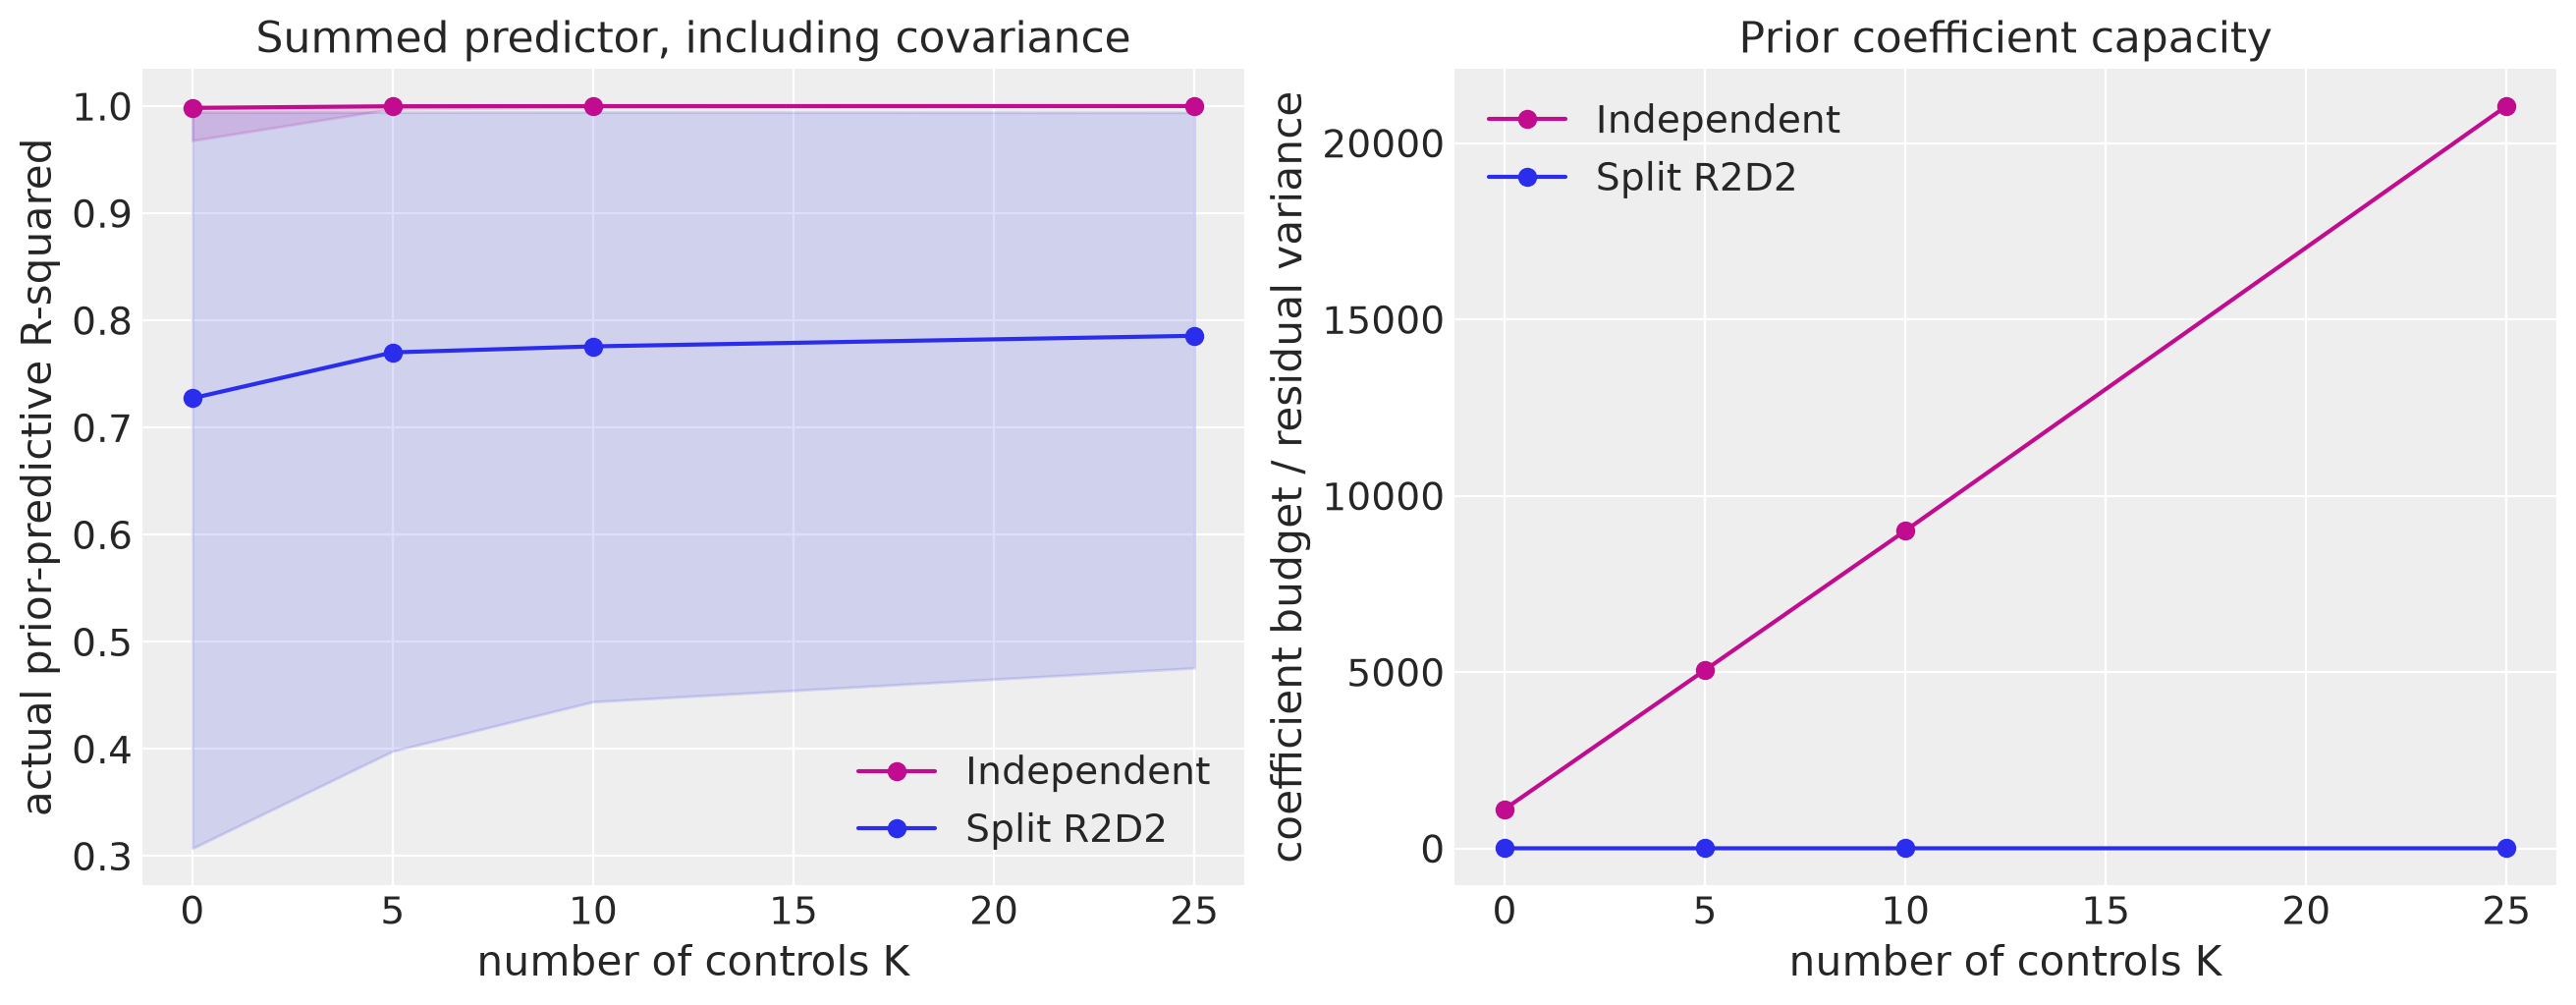

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for arm, color in ARM_COLORS.items():
    subset = prior_table.query("arm == @arm").sort_values("K")
    axes[0].plot(subset["K"], subset["r2_median"], marker="o", color=color, label=arm)
    axes[0].fill_between(subset["K"], subset["r2_q05"], subset["r2_q95"], color=color, alpha=0.15)
    axes[1].plot(subset["K"], subset["coefficient_budget_ratio_median"], marker="o", color=color, label=arm)
axes[0].set(xlabel="number of controls K", ylabel="actual prior-predictive R-squared", title="Summed predictor, including covariance")
axes[1].set(xlabel="number of controls K", ylabel="coefficient budget / residual variance", title="Prior coefficient capacity")
for ax in axes:
    ax.legend()
plt.show()


The left panel is the model-level prior-predictive quantity: temporal variation in the **summed** predictor, including covariance among media, controls, and seasonality. It is therefore design-dependent. The right panel isolates the coefficient-capacity mechanism: independent fixed-scale coefficients accumulate capacity as columns are added, while R2D2 divides one budget across controls and Fourier terms.

Neither panel establishes posterior accuracy. It explains why the broad-control comparison is worth testing; the repeated ROAS study below supplies the comparative evidence.


## Fitting and diagnostics

The helper below retains diagnostics for every fit. A fit passes only with zero divergences, maximum $\hat R\leq1.01$, and minimum bulk and tail ESS of at least 200. Repeated-study summaries exclude failed fits and report the exclusion rate. A divergent fit is not treated as trustworthy merely because its point estimate happens to be close to the truth.


In [12]:
def total_roas_data(mmm: MMM) -> xr.DataArray:
    joint_increment = mmm.incrementality.compute_joint_incremental_contribution(
        frequency="all_time"
    )
    spend = float(mmm.data.get_channel_spend().sum())
    return joint_increment / spend


def total_roas(mmm: MMM) -> np.ndarray:
    return total_roas_data(mmm).values.ravel()


def diagnostic_summary(mmm: MMM, dataset_truth: dict, k: int, arm: str) -> dict:
    posterior = mmm.idata["posterior"]
    sample_stats = mmm.idata["sample_stats"]
    parameter_names = [rv.name for rv in mmm.model.free_RVs if rv.name in posterior]
    diagnostics = az.summary(posterior, var_names=parameter_names, kind="diagnostics")

    divergences = int(sample_stats["diverging"].sum())
    max_r_hat = float(diagnostics["r_hat"].max())
    min_ess_bulk = float(diagnostics["ess_bulk"].min())
    min_ess_tail = float(diagnostics["ess_tail"].min())
    diagnostic_pass = (
        divergences == 0
        and max_r_hat <= 1.01
        and min_ess_bulk >= 200
        and min_ess_tail >= 200
    )
    return {
        "K": k,
        "arm": arm,
        "truth": dataset_truth["total_roas"],
        "divergences": divergences,
        "max_r_hat": max_r_hat,
        "min_ess_bulk": min_ess_bulk,
        "min_ess_tail": min_ess_tail,
        "diagnostic_pass": diagnostic_pass,
    }


def fit_for_k(
    dataset: pd.DataFrame,
    dataset_truth: dict,
    k: int,
    arm: str,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Ordinary MMM fit, retained for the illustration and reuse checks."""
    mmm = build_mmm(dataset, k, arm)
    mmm.fit(
        dataset.drop(columns="y"),
        dataset["y"],
        random_seed=seed,
        progressbar=False,
    )
    return total_roas(mmm), diagnostic_summary(mmm, dataset_truth, k, arm)


def build_mmm_for_dataset(dataset: pd.DataFrame, k: int, arm: str) -> MMM:
    """Build, but do not sample, one MMM for a same-shape simulated dataset."""
    X = dataset.drop(columns="y")
    y = dataset["y"]
    mmm = build_mmm(dataset, k, arm)
    mmm.build_model(X, y)
    mmm._fit_data_group = mmm.create_fit_data(X, y)
    return mmm


def make_r2d2_scale_mutable(mmm: MMM) -> None:
    """Expose Split R2D2's empirical-Bayes scale as mutable model data.

    This narrowly scoped graph adjustment is made once, before compilation.
    Subsequent nutpie ``with_data`` calls can then update the scale together
    with the usual MMM data variables.
    """
    rv = mmm.model.named_vars["r2d2_total_sigma"]
    scale_constant = rv.owner.inputs[-1]
    with mmm.model:
        scale_data = pm.Data("r2d2_total_sigma_scale", scale_constant.data)
    rv.owner.inputs[-1] = scale_data


def r2d2_scale_from_model(mmm: MMM) -> float:
    return float(mmm.model.named_vars["r2d2_total_sigma"].owner.inputs[-1].data)


def reusable_data(mmm: MMM, arm: str) -> dict[str, np.ndarray | float]:
    values = {
        variable.name: variable.get_value(borrow=False)
        for variable in mmm.model.data_vars
    }
    if arm == "Split R2D2":
        values["r2d2_total_sigma_scale"] = r2d2_scale_from_model(mmm)
    return values


def compile_reusable_mmm(template: MMM, arm: str):
    if arm == "Split R2D2":
        make_r2d2_scale_mutable(template)
    free_variable_names = [rv.name for rv in template.model.free_RVs]
    return nutpie.compile_pymc_model(template.model, var_names=free_variable_names)


def attach_model_outputs(idata: xr.DataTree, mmm: MMM) -> xr.DataTree:
    """Restore the groups and deterministics used by MMM post-processing."""
    with mmm.model:
        idata["/posterior"] = pm.compute_deterministics(
            idata["/posterior"], merge_dataset=True
        )
        with contextlib.redirect_stdout(io.StringIO()):
            model_data = pm.sample_prior_predictive(
                draws=1, var_names=[], return_inferencedata=True
            )
    for group in ("constant_data", "observed_data"):
        if group in model_data:
            idata[f"/{group}"] = model_data[group]
    fit_data = mmm.create_fit_data_group()
    if fit_data is not None:
        idata["/fit_data"] = fit_data
    return idata


def sample_reusable_mmm(
    compiled_model,
    mmm: MMM,
    dataset_truth: dict,
    k: int,
    arm: str,
    seed: int,
) -> tuple[np.ndarray, dict]:
    sampler_kwargs = {
        key: value
        for key, value in SAMPLER_CONFIG.items()
        if key not in {"nuts_sampler", "target_accept"}
    }
    idata = nutpie.sample(
        compiled_model.with_data(**reusable_data(mmm, arm)),
        seed=seed,
        cores=SAMPLER_CONFIG["chains"],
        progress_bar=False,
        target_accept=SAMPLER_CONFIG["target_accept"],
        **sampler_kwargs,
    )
    mmm.idata = attach_model_outputs(idata, mmm)
    return total_roas(mmm), diagnostic_summary(mmm, dataset_truth, k, arm)


## One-dataset mechanism illustration

This fixed dataset makes posterior movement across $K$ visible. Read each interval as an illustration of one realization, not as a model-ranking result: finite-sample correlations can favor either prior system. The vertical truth line is known only because this is simulated data. The repeated paired experiment below is the evidence for systematic differences.


In [13]:
illustration_draws = {}
illustration_records = []
for k in K_GRID:
    for arm in ARM_NAMES:
        draws, info = fit_for_k(data, truth, k, arm, seed=SEED)
        illustration_draws[k, arm] = draws
        q05, median, q95 = np.quantile(draws, [0.05, 0.50, 0.95])
        illustration_records.append(
            info
            | {
                "posterior_mean": draws.mean(),
                "posterior_sd": draws.std(ddof=1),
                "q05": q05,
                "median": median,
                "q95": q95,
            }
        )
illustration = pd.DataFrame(illustration_records)
illustration


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

,K,arm,truth,divergences,max_r_hat,min_ess_bulk,min_ess_tail,diagnostic_pass,posterior_mean,posterior_sd,q05,median,q95
0,0,Independent,2.013322,0,1.0,1181.0,943.0,True,2.029614,0.579360,1.208211,1.956727,3.094677
1,0,Split R2D2,2.013322,0,1.0,1265.0,1062.0,True,2.035806,0.594379,1.182089,1.970244,3.093302
2,5,Independent,2.013322,0,1.0,1059.0,913.0,True,1.835874,0.465474,1.202567,1.786361,2.605230
3,5,Split R2D2,2.013322,0,1.0,1568.0,1225.0,True,1.734280,0.425612,1.127076,1.681995,2.499778
4,10,Independent,2.013322,0,1.0,1138.0,1298.0,True,2.158014,0.439412,1.524961,2.121095,2.920046
5,10,Split R2D2,2.013322,0,1.0,1710.0,1194.0,True,1.935363,0.416806,1.322603,1.904016,2.693982
6,25,Independent,2.013322,0,1.0,1072.0,1160.0,True,2.425627,0.539416,1.642766,2.372820,3.380320
7,25,Split R2D2,2.013322,0,1.0,1605.0,1399.0,True,1.968115,0.431966,1.332091,1.944313,2.725487


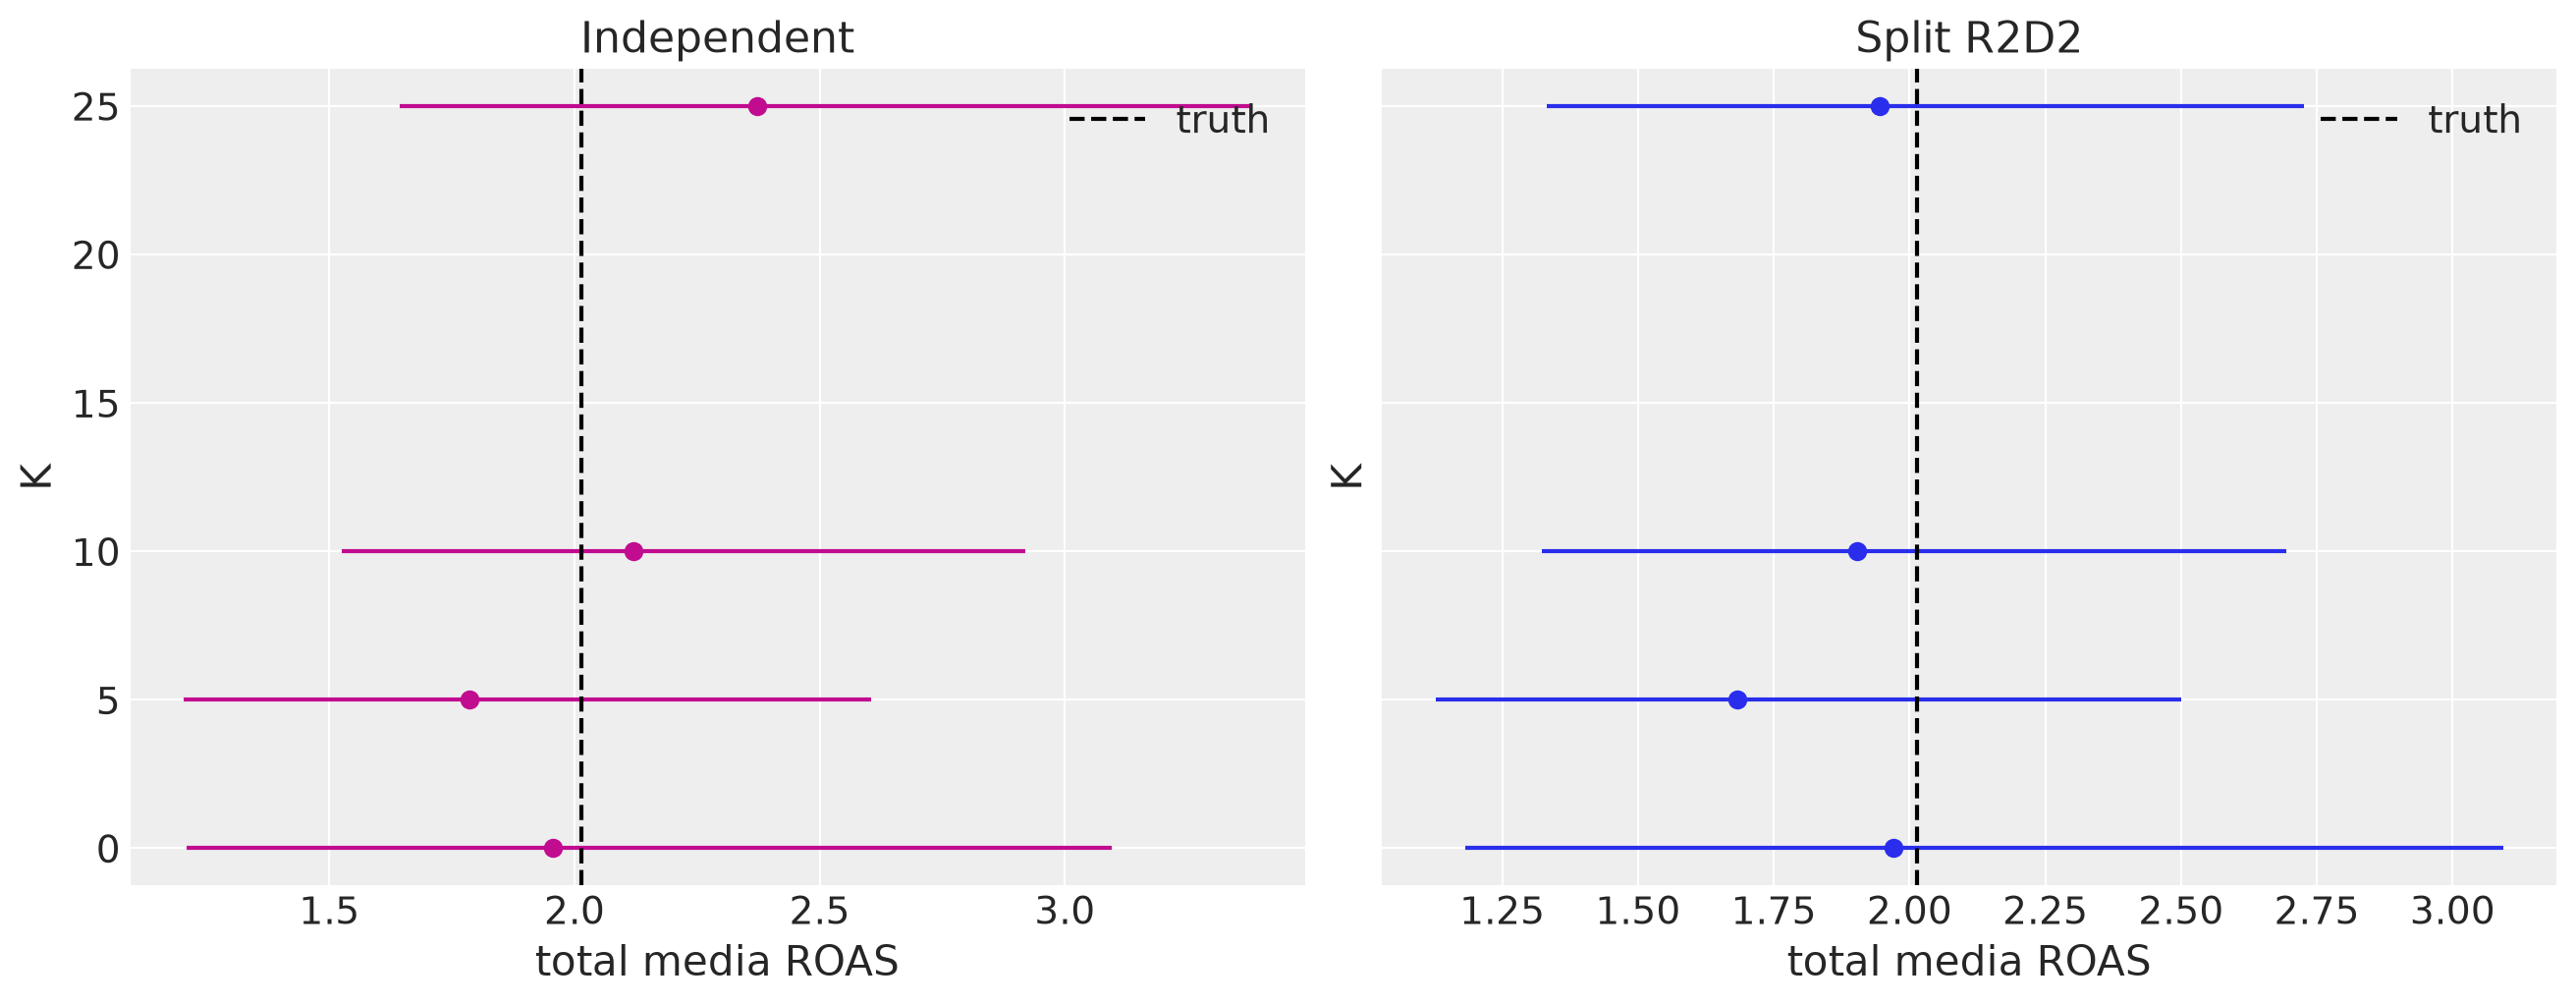

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout="constrained")
for ax, arm in zip(axes, ARM_NAMES, strict=True):
    subset = illustration.query("arm == @arm").sort_values("K")
    ax.errorbar(
        subset["median"],
        subset["K"],
        xerr=[subset["median"] - subset["q05"], subset["q95"] - subset["median"]],
        fmt="o",
        color=ARM_COLORS[arm],
    )
    ax.axvline(truth["total_roas"], color="black", linestyle="--", label="truth")
    ax.set(title=arm, xlabel="total media ROAS", ylabel="K")
    ax.legend()
plt.show()


## Repeated experiment: primary evidence

The study uses `N_REPS=50` paired replications. Within each replication, every prior system and value of $K$ sees the same generated dataset, so the central comparisons are paired differences rather than differences between unrelated simulations.

The summaries report empirical SD of posterior means, empirical SD of estimation errors, mean posterior SD, interval length, bias, RMSE, and 90% interval coverage. Empirical SD of estimation error is the repeated-sampling precision measure because the exact ROAS varies slightly across generated datasets. Paired contrasts are `Split R2D2 - Independent`: a negative difference in posterior SD, interval length, absolute error, or squared error favors Split R2D2.

Coverage remains descriptive even at 50 repetitions. The table reports a binomial Monte-Carlo interval for each observed coverage rate, so small between-arm coverage differences should not be over-interpreted.

:::{dropdown} Reusing a compiled model in this simulation

The repeated study fits the same six model structures—three values of $K$ times two prior systems—to many same-shape synthetic datasets. To reduce wall-clock time, it compiles each structure once with nutpie and replaces its named `pm.Data` inputs before each subsequent fit. Split R2D2 also replaces its data-derived total-scale input.

This is an experiment-runtime optimization, not a normal MMM fitting workflow and not an inferential method. A fresh model is still built for each dataset to obtain its transformed data and to calculate ROAS; only the expensive nutpie compilation is reused. The notebook checks reused fits against ordinary fresh fits before relying on this path.
:::


### Reuse-equivalence check

Before the large repeated study, the accelerated path is compared with ordinary fresh MMM fits on two fixed datasets for every prior system and value of $K$. Agreement is judged on diagnostics and total-ROAS posterior summaries, allowing for ordinary Monte-Carlo variation between independent chains.


In [15]:
EQUIVALENCE_SEEDS = [SEED + 1, SEED + 2]


def fit_fresh_mmm(
    dataset: pd.DataFrame, k: int, arm: str, seed: int
) -> MMM:
    mmm = build_mmm(dataset, k, arm)
    mmm.fit(dataset.drop(columns="y"), dataset["y"], random_seed=seed, progressbar=False)
    return mmm


def roas_summary_with_mcse(mmm: MMM) -> dict:
    draws = total_roas_data(mmm)
    q05, q95 = np.quantile(draws.values, [0.05, 0.95])
    return {
        "mean": float(draws.mean()),
        "mcse_mean": float(az.mcse(draws, method="mean")),
        "sd": float(draws.std(ddof=1)),
        "interval_length": float(q95 - q05),
    }


def reuse_equivalence_check(seeds: list[int] = EQUIVALENCE_SEEDS) -> pd.DataFrame:
    records = []
    for k in REPEATED_K_GRID:
        for arm in ARM_NAMES:
            template_data, _ = simulate(SEED)
            template = build_mmm_for_dataset(template_data, k, arm)
            compiled_model = compile_reusable_mmm(template, arm)
            for seed in seeds:
                dataset, truth = simulate(seed)
                fresh = fit_fresh_mmm(dataset, k, arm, seed)
                reused = build_mmm_for_dataset(dataset, k, arm)
                _, reused_diagnostics = sample_reusable_mmm(
                    compiled_model, reused, truth, k, arm, seed
                )
                fresh_summary = roas_summary_with_mcse(fresh)
                reused_summary = roas_summary_with_mcse(reused)
                pooled_mcse = np.hypot(
                    fresh_summary["mcse_mean"], reused_summary["mcse_mean"]
                )
                mean_difference = reused_summary["mean"] - fresh_summary["mean"]
                records.append(
                    {
                        "seed": seed,
                        "K": k,
                        "arm": arm,
                        "fresh_divergences": int(
                            fresh.idata["sample_stats"]["diverging"].sum()
                        ),
                        "reused_divergences": reused_diagnostics["divergences"],
                        "mean_difference": mean_difference,
                        "pooled_mcse_mean": pooled_mcse,
                        "sd_ratio": reused_summary["sd"] / fresh_summary["sd"],
                        "interval_length_ratio": (
                            reused_summary["interval_length"]
                            / fresh_summary["interval_length"]
                        ),
                    }
                )
    comparison = pd.DataFrame(records)
    comparison["mean_agrees"] = (
        comparison["mean_difference"].abs()
        <= 4 * comparison["pooled_mcse_mean"]
    )
    comparison["spread_agrees"] = (
        comparison["sd_ratio"].between(0.85, 1.15)
        & comparison["interval_length_ratio"].between(0.85, 1.15)
    )
    comparison["diagnostics_agree"] = (
        comparison["fresh_divergences"].eq(0)
        & comparison["reused_divergences"].eq(0)
    )
    assert comparison[
        ["mean_agrees", "spread_agrees", "diagnostics_agree"]
    ].to_numpy().all(), "Compiled-data reuse did not match fresh MMM fits."
    return comparison


reuse_equivalence = reuse_equivalence_check()
reuse_equivalence


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier_offset, r2d2_weights, r2d2_total_sigma, r2d2_r2, gamma_control_offset, intercept_contribution]


Output()

Output()

Sampling: []


,seed,K,arm,fresh_divergences,reused_divergences,mean_difference,pooled_mcse_mean,sd_ratio,interval_length_ratio,mean_agrees,spread_agrees,diagnostics_agree
0,43,5,Independent,0,0,-0.007872,0.011176,1.015200,1.000694,True,True,True
1,44,5,Independent,0,0,-0.007869,0.012255,0.965054,0.960728,True,True,True
2,43,5,Split R2D2,0,0,-0.007462,0.010449,0.994336,0.983949,True,True,True
3,44,5,Split R2D2,0,0,-0.001825,0.011142,0.975011,0.963729,True,True,True
4,43,10,Independent,0,0,-0.002610,0.011170,1.027329,1.050177,True,True,True
5,44,10,Independent,0,0,-0.006444,0.009951,0.991702,0.994336,True,True,True
6,43,10,Split R2D2,0,0,0.001892,0.007468,0.992681,0.998228,True,True,True
7,44,10,Split R2D2,0,0,-0.005676,0.009362,1.010963,0.994093,True,True,True
8,43,25,Independent,0,0,0.000261,0.013093,0.973132,0.999652,True,True,True
9,44,25,Independent,0,0,0.021197,0.012184,1.038733,1.034483,True,True,True


In [16]:
N_REPS = 50


def summarize_draws(draws: np.ndarray, true_value: float) -> dict:
    q05, q95 = np.quantile(draws, [0.05, 0.95])
    posterior_mean = float(draws.mean())
    error = posterior_mean - true_value
    return {
        "posterior_mean": posterior_mean,
        "posterior_sd": float(draws.std(ddof=1)),
        "interval_length": float(q95 - q05),
        "error": error,
        "absolute_error": abs(error),
        "squared_error": error**2,
        "covers": bool(q05 <= true_value <= q95),
    }


def run_experiment(n_reps: int = N_REPS, base_seed: int = SEED) -> pd.DataFrame:
    """Run by model structure so each of six graphs compiles only once."""
    records = []
    for k in REPEATED_K_GRID:
        for arm in ARM_NAMES:
            template_data, _ = simulate(base_seed)
            template = build_mmm_for_dataset(template_data, k, arm)
            compiled_model = compile_reusable_mmm(template, arm)
            for rep in range(n_reps):
                seed = base_seed + rep
                rep_data, rep_truth = simulate(seed)
                mmm = build_mmm_for_dataset(rep_data, k, arm)
                draws, diagnostics = sample_reusable_mmm(
                    compiled_model, mmm, rep_truth, k, arm, seed
                )
                records.append(
                    {"rep": rep}
                    | diagnostics
                    | summarize_draws(draws, rep_truth["total_roas"])
                )
    return pd.DataFrame(records)


repetitions = run_experiment()


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


In [17]:
def wilson_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    half_width = z * np.sqrt(
        proportion * (1 - proportion) / total + z**2 / (4 * total**2)
    ) / denominator
    return center - half_width, center + half_width


def repeated_summary(results: pd.DataFrame) -> pd.DataFrame:
    valid = results[results["diagnostic_pass"]]
    performance = (
        valid.groupby(["K", "arm"])
        .agg(
            n_valid=("rep", "size"),
            n_covered=("covers", "sum"),
            empirical_sd_estimate=("posterior_mean", "std"),
            empirical_sd_error=("error", "std"),
            mean_posterior_sd=("posterior_sd", "mean"),
            mean_interval_length=("interval_length", "mean"),
            bias=("error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(x.mean())),
            coverage=("covers", "mean"),
        )
        .reset_index()
    )
    coverage_intervals = performance.apply(
        lambda row: wilson_interval(int(row["n_covered"]), int(row["n_valid"])),
        axis=1,
        result_type="expand",
    )
    performance[["coverage_mc_low", "coverage_mc_high"]] = coverage_intervals
    diagnostics = (
        results.groupby(["K", "arm"])
        .agg(
            n_total=("rep", "size"),
            failed_fits=("diagnostic_pass", lambda x: (~x).sum()),
            total_divergences=("divergences", "sum"),
            worst_r_hat=("max_r_hat", "max"),
            minimum_ess_bulk=("min_ess_bulk", "min"),
            minimum_ess_tail=("min_ess_tail", "min"),
        )
        .reset_index()
    )
    summary = diagnostics.merge(performance, on=["K", "arm"], how="left")
    summary["n_valid"] = summary["n_valid"].fillna(0).astype(int)
    summary["exclusion_rate"] = summary["failed_fits"] / summary["n_total"]
    return summary


repeated_results = repeated_summary(repetitions)
repeated_results


,K,arm,n_total,failed_fits,total_divergences,worst_r_hat,minimum_ess_bulk,minimum_ess_tail,n_valid,n_covered,empirical_sd_estimate,empirical_sd_error,mean_posterior_sd,mean_interval_length,bias,rmse,coverage,coverage_mc_low,coverage_mc_high,exclusion_rate
0,5,Independent,50,0,0,1.01,668.0,672.0,50,42,0.492893,0.490604,0.436118,1.415999,0.029543,0.486571,0.840000,0.714855,0.916627,0.00
1,5,Split R2D2,50,0,0,1.00,882.0,909.0,50,43,0.494849,0.492782,0.435847,1.415287,0.033349,0.488968,0.860000,0.738135,0.930493,0.00
2,10,Independent,50,0,0,1.01,602.0,670.0,50,44,0.485745,0.483033,0.400116,1.298548,-0.016682,0.478470,0.880000,0.761949,0.943825,0.00
3,10,Split R2D2,50,0,0,1.01,595.0,696.0,50,43,0.464542,0.462061,0.396335,1.286791,-0.022713,0.457981,0.860000,0.738135,0.930493,0.00
4,25,Independent,50,1,26,1.01,430.0,299.0,49,43,0.559298,0.556568,0.449041,1.454418,0.049701,0.553097,0.877551,0.757553,0.942653,0.02
5,25,Split R2D2,50,0,0,1.01,457.0,631.0,50,46,0.495490,0.492538,0.425542,1.378046,0.022986,0.488129,0.920000,0.811615,0.968451,0.00


In [18]:
def paired_contrasts(results: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "posterior_sd",
        "interval_length",
        "error",
        "absolute_error",
        "squared_error",
    ]
    valid = results[results["diagnostic_pass"]]
    wide = valid.pivot(index=["rep", "K"], columns="arm", values=metrics).dropna()
    if wide.empty:
        return pd.DataFrame(
            {"message": ["No replication passed diagnostics for both prior systems."]}
        )
    contrasts = pd.DataFrame(index=wide.index)
    for metric in metrics:
        contrasts[metric] = (
            wide[metric]["Split R2D2"] - wide[metric]["Independent"]
        )
    return (
        contrasts.groupby("K")
        .agg(["mean", "sem", "count"])
        .rename_axis(columns=["metric", "summary"])
    )


paired_results = paired_contrasts(repetitions)
paired_results


metric  posterior_sd                 interval_length                  \
summary         mean       sem count            mean       sem count   
K                                                                      
5          -0.000271  0.003498    50       -0.000712  0.011657    50   
10         -0.003781  0.004473    50       -0.011757  0.013061    50   
25         -0.024432  0.006965    49       -0.076281  0.021813    49   

metric      error                 absolute_error                  \
summary      mean       sem count           mean       sem count   
K                                                                  
5        0.003805  0.010562    50       0.003898  0.010548    50   
10      -0.006030  0.012517    50      -0.010184  0.011161    50   
25      -0.028916  0.022651    49      -0.032927  0.021267    49   

metric  squared_error                  
summary          mean       sem count  
K                                      
5            0.002338  0.012794    50  
10          -0.019187  0.018068    50  
25          -0.063133  0.041582    49

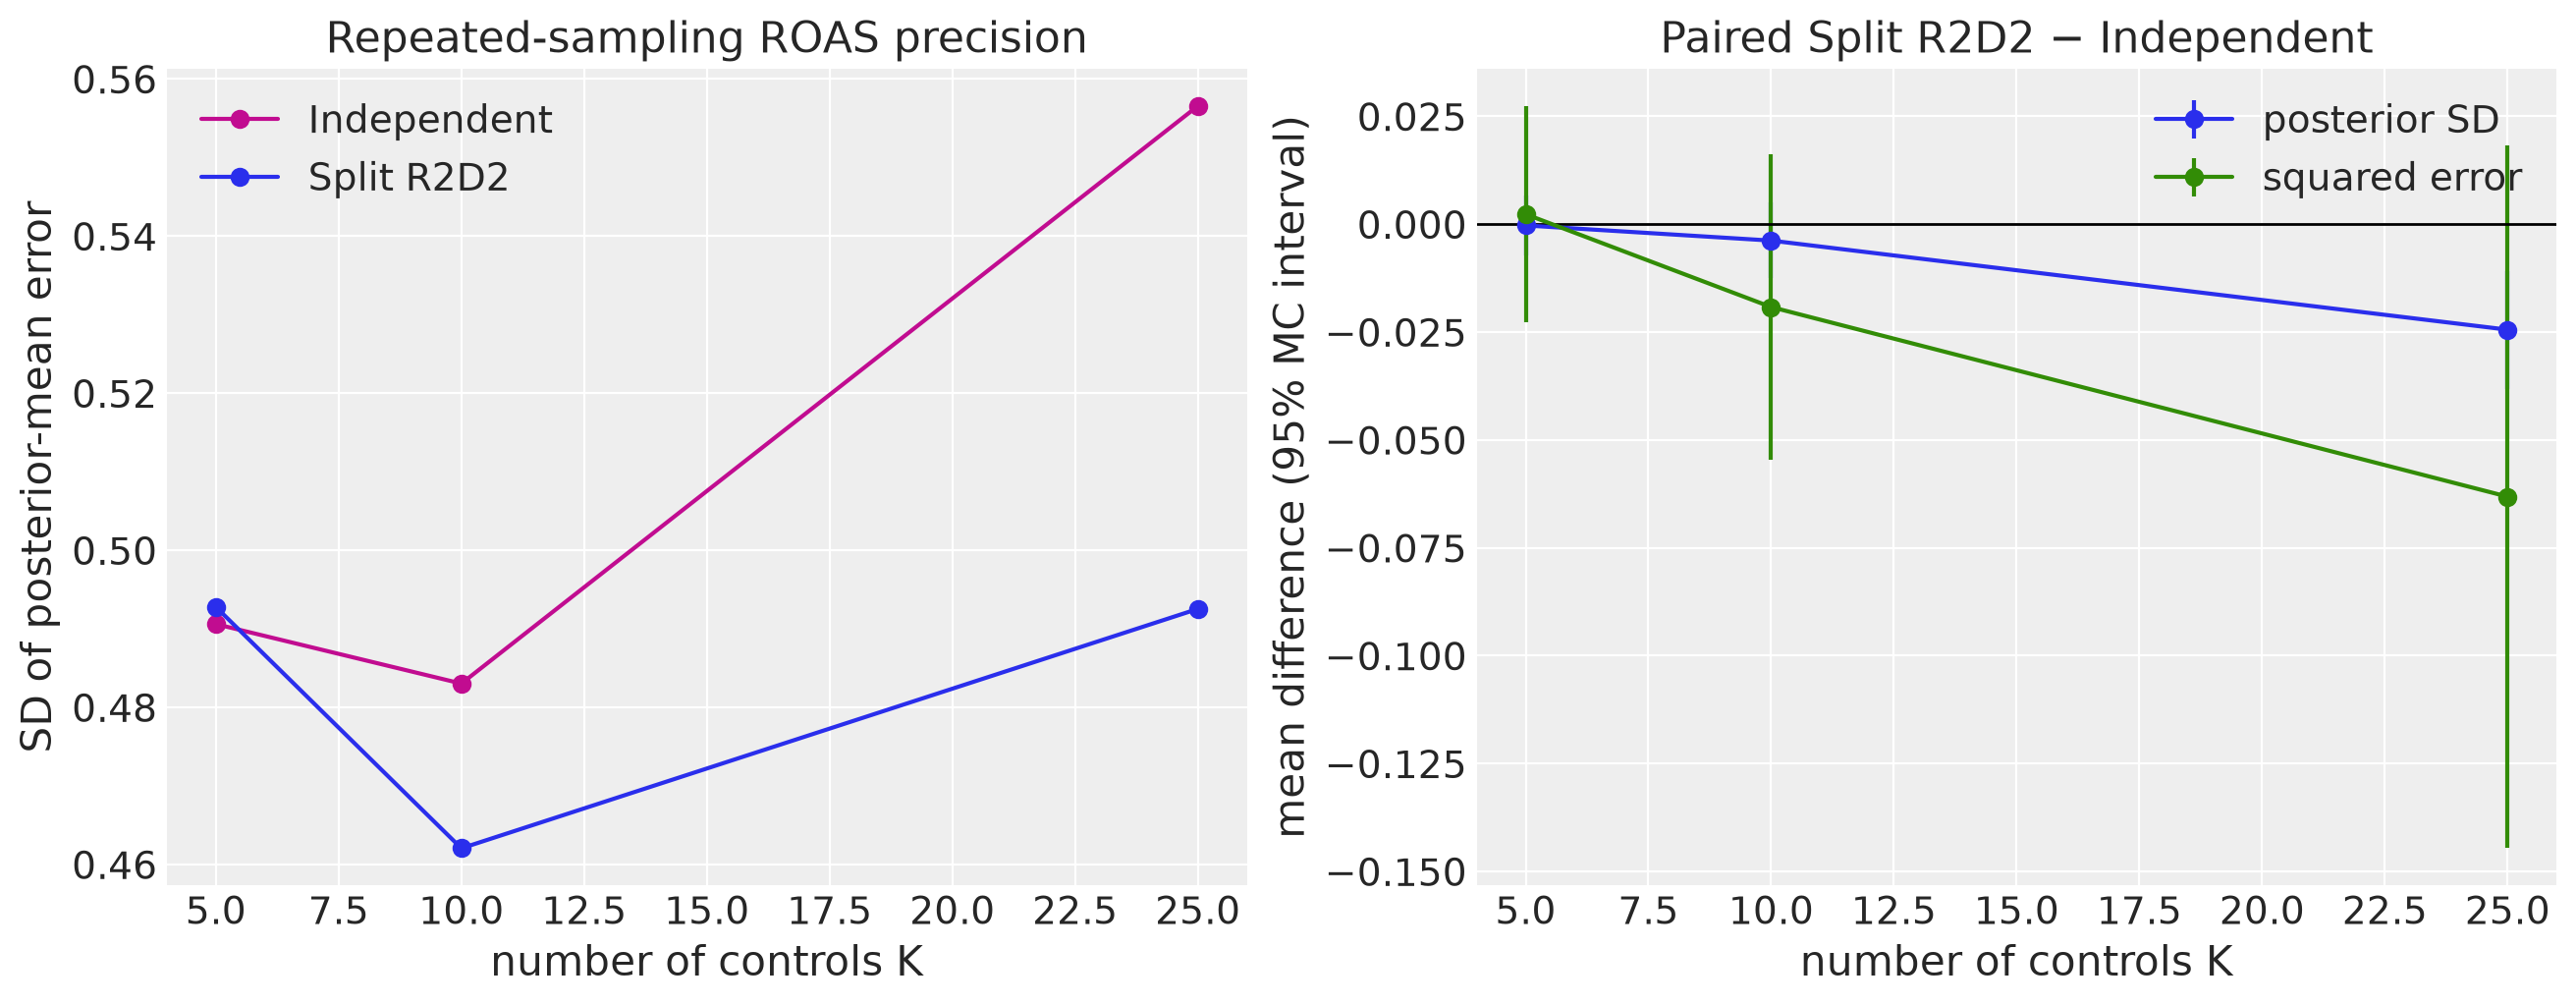

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for arm, color in ARM_COLORS.items():
    subset = repeated_results.query("arm == @arm").sort_values("K")
    axes[0].plot(
        subset["K"],
        subset["empirical_sd_error"],
        marker="o",
        color=color,
        label=arm,
    )
axes[0].set(
    title="Repeated-sampling ROAS precision",
    xlabel="number of controls K",
    ylabel="SD of posterior-mean error",
)

for metric, color, label in [
    ("posterior_sd", "C0", "posterior SD"),
    ("squared_error", "C2", "squared error"),
]:
    mean = paired_results[(metric, "mean")]
    sem = paired_results[(metric, "sem")]
    axes[1].errorbar(
        mean.index,
        mean,
        yerr=1.96 * sem,
        marker="o",
        color=color,
        label=label,
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(
    title="Paired Split R2D2 − Independent",
    xlabel="number of controls K",
    ylabel="mean difference (95% MC interval)",
)
for ax in axes:
    ax.legend()
plt.show()


## Interpretation

Read the repeated results as three practical transitions:

- **$5\rightarrow10$:** adding useful neutral controls does not produce a stable separation between the prior systems in this experiment. Paired posterior-SD and error contrasts are small relative to their Monte-Carlo uncertainty.
- **$10\rightarrow25$:** this is the primary stress test. Adding mostly nuisance dimensions increases repeated-sampling ROAS error for both systems, but Split R2D2 has lower mean posterior SD and shorter intervals. Its paired K=25 posterior-SD contrast is $-0.024\pm0.007$ (SEM), and its interval-length contrast is $-0.076\pm0.022$.
- **$5\rightarrow25$:** the broad control list is less precise than the short list, but the split budget limits that loss. The mean paired squared-error contrast at K=25 is negative ($-0.063\pm0.042$), although its Monte-Carlo uncertainty is still large enough that this run should not be read as proof of an accuracy improvement.

The 50-replication run had one failed Independent K=25 fit (26 divergences), which the prespecified diagnostic policy excluded. All other 299 fits had zero divergences. The coverage intervals in the table overlap substantially, so coverage is descriptive rather than a basis for choosing an arm.

The practical conclusion is deliberately narrow. Split R2D2 gives a broad-control MMM a dimension-aware starting point by preventing the control-and-seasonality allowance from expanding solely because the list is longer. It does not make inappropriate controls safe, solve finite-sample attribution ambiguity, or guarantee a better estimate in every realization.

### Limitations

- Controls and seasonality are neutral here; the notebook does not study genuine confounding or spend that follows the calendar.
- The R2D2 budget covers controls and Fourier terms relative to residual variation, not directly as a fraction of original target variance.
- The flat Dirichlet initially treats standardized coefficients symmetrically even though the DGP orders them by importance.
- Native R2D2 changes residual-scale geometry as well as coefficient shrinkage.
- Fifty replications improve precision over the exploratory run, but coverage and paired error differences still carry Monte-Carlo uncertainty.


## References

- Riha, A. E., Lindgren, L., Kohns, D., Bürkner, P.-C., & Vehtari, A. (2026). [*To select or not to select: predictively consistent priors instead of model selection*](https://arxiv.org/abs/2606.22850).
- Zhang, Y. D., Naughton, B. P., Bondell, H. D., & Reich, B. J. (2022). [Bayesian Regression Using a Prior on the Model Fit: The R2-D2 Shrinkage Prior](https://doi.org/10.1080/01621459.2020.1825449).
- Cinelli, C., Forney, A., & Pearl, J. (2024). [A Crash Course in Good and Bad Controls](https://doi.org/10.1177/00491241221099552).
- Jin, Y., Wang, Y., Sun, Y., Chan, D., & Koehler, J. (2017). [Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects](https://research.google/pubs/pub46001/).


In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,pymc


Last updated: Wed, 09 Sep 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4
pymc          : 6.2.0

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
nutpie        : 0.16.11
pandas        : 2.3.3
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
pytensor      : 3.2.4
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

